<a href="https://colab.research.google.com/github/amathe1/Neural_Networks/blob/main/understanding_and_fixing_overfitting_issue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overfitting and how to prevent it using below techniques**

- Dropout Layer
- Early Stopping
- L2 Regularization

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris    # it means bring me load_iris method from datasets module inside sklearn library (importing iris data set from Scikit-learn)
from sklearn.model_selection import train_test_split # Existing utility in sklearn used to split data into Train, Test data
from sklearn.preprocessing import StandardScaler # StanardScaler/Z-Scalar normalization technique for data normalization

import matplotlib.pyplot as plt # importing matplotlib for plotting output graph

In [2]:
#Step 2 — Load Dataset
data = load_iris()
X = data.data
y = data.target

In [3]:
#Step 3 : Train/Validate split : Splitting the input data for training & testing using train_test_split(), note we mentioned the % of test data size


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.4, random_state=42
)

print(X.shape)
print(y.shape)
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(150, 4)
(150,)
(90, 4)
(60, 4)
(90,)
(60,)


In [4]:
#Step 4 : Train & Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.4, random_state=42
)

In [5]:
#Step 5 : Normalize

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
# type(X_train)
# type(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)



In [6]:
# Part 1 - Overfitting model
class OverfitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,3)
        )

    def forward(self,x):
        return self.net(x)


In [7]:
# Training Function

def train_model(model, optimizer, epochs=200):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        pred = model(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

In [8]:
# Train
model1 = OverfitModel()
opt1 = optim.Adam(model1.parameters(), lr=0.01)

train1, val1 = train_model(model1, opt1)


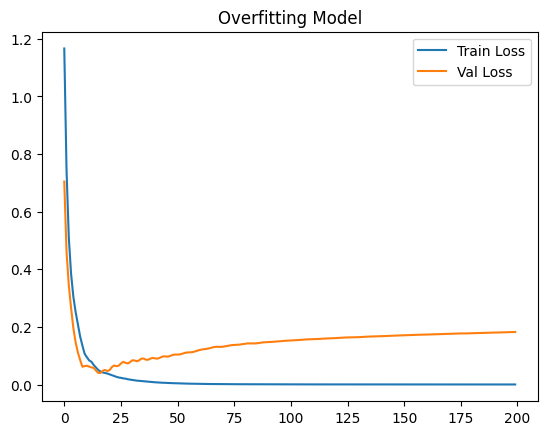

In [9]:
# Visualize Overfitting
plt.plot(train1,label="Train Loss")
plt.plot(val1,label="Val Loss")
plt.legend()
plt.title("Overfitting Model")
plt.show()


**Regularized model :**
- Drop out layer
- L2 regularization
- Early stopping

In [10]:
# Regularized model

class RegularizedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,128),
            nn.ReLU(),
            nn.Dropout(0.5), # Applying dropout to avoid overfitting issue (switching off 50% if neurons in hidden layer1)
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.5), # Applying dropout to avoid overfitting issue (switching off 50% if neurons in hidden layer2)
            nn.Linear(64,3)
        )

    def forward(self,x):
        return self.net(x)

In [11]:
# Early stopping training
def train_with_early_stopping(model, optimizer, patience=15):
    criterion = nn.CrossEntropyLoss()

    best_loss = float('inf')
    counter = 0

    train_losses, val_losses = [], []

    for epoch in range(300):
        model.train()
        pred = model(X_train)
        loss = criterion(pred,y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        val_pred = model(X_val)
        val_loss = criterion(val_pred,y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

    return train_losses,val_losses

In [12]:
#Train regularized
# (L2 via weight decay)

model2 = RegularizedModel()
opt2 = optim.Adam(model2.parameters(), lr=0.01, weight_decay=1e-3)

train2, val2 = train_with_early_stopping(model2, opt2)

Early stopping triggered


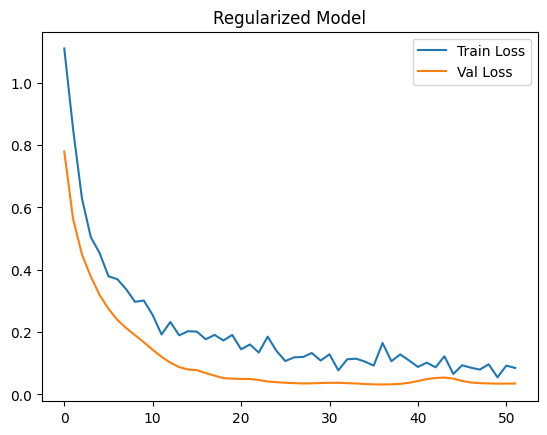

In [13]:
# Visualize after fix
plt.plot(train2,label="Train Loss")
plt.plot(val2,label="Val Loss")
plt.legend()
plt.title("Regularized Model")
plt.show()